# 反応器の圧力損失と形式選択 — 軸流深床 → Catofin 浅床・多基並列

**目的**: 反応器設計レビューで「0.5 bar 低圧固定床では圧力損失を無視できない」と指摘を受けた。
本ノートはその経緯と最終的な反応器形式(**Catofin型 浅床・大断面・多基並列スイング**)の選択をレポート用に 1 冊へまとめる。

物語:
1. **(a) 旧モデル**: 軸流・深い充填層 PFR。**圧損ゼロ**を仮定していた。
2. **(b) 発見**: Ergun 式を軸方向 ODE に連成すると、現実的な触媒粒径(2–6mm)では軸流深床は
   **どの床長でも 0.5 bar で ΔP 過大(実質全損)= infeasible**。
3. **(c) 解**: **Catofin型 浅床・多基並列**。浅床 $L_{bed}\le1$m で 1 基あたり流路長を短くして圧損を下げ、
   並列基数 $N_{online}$ で大流量を低空塔速度で通す。捨てたのは「軸流」でなく「**深床**」。
4. **(d) 結論**: 0.5 bar は平衡転化率のため不可欠 → 圧力では妥協できない → **浅床+多基(Catofin)が必然**。
   実機 Lummus Catofin(減圧・浅床・多基スイング)と同じ設計思想に物理で到達する。

> 径方向流(radial flow)も一時検討したが、内部品/分配板/再生温度の不確かさが大きく撤去し、
> 浅床多基(Catofin)を採用した。本ノートは現採用形式 = Catofin で検証する。
> 反応器(`units/reactors/catofin.py`, 物理は `swing.py` を per-vessel 流用)は純 Python (scipy ODE)。HYSYS 不要。


## 補足: 反応の性質と反応器の分類 (レポートの厚み用)

**PDH 反応器は「触媒固定床反応器(catalytic fixed-bed)」に分類される。ラジカル反応器ではない。**
反応器の分類は**目的反応のメカニズム**で決まり、PDH の目的反応=触媒脱水素(Cr₂O₃ 表面で進む)だから。

| 反応 | 性質 | モデル |
|---|---|---|
| r1: C₃H₈→C₃H₆+H₂ (**主・目的**) | **触媒**脱水素・**吸熱** | 活性係数 `a` あり(触媒依存) |
| r2: C₃H₈→C₂H₄+CH₄ (副・クラッキング) | **気相ラジカル(熱分解)** | `r2=k₂·P_A`、`a` **なし**(触媒非依存=熱的) |
| r3: C₂H₄+H₂→C₂H₆ (副・水素化) | 気相/逐次 | `a` なし |

- 目的の脱水素は**触媒反応**。ホットスポット/熱暴走の悩みは**発熱ラジカル反応(OCM等)の話**で、
  PDH 主反応は**強吸熱**(ΔH≈+124 kJ/mol)で床は**冷える** → 反応中はホットスポットも暴走も起きない。
- ラジカル/発熱が効くのは (i) クラッキング副反応の選択率(低温・低圧・短滞留で抑制 → 0.5 bar が選択率にも効く)と
  (ii) コーク燃焼=再生工程(強発熱・ホットスポット本丸。Catofin はここをスイング多基で扱う)。
- 結論: **PDH は触媒+吸熱なので固定床が標準で妥当**。形式の選択は **圧力損失**で決まる。


In [1]:
import sys, os, math, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# プロジェクトルートを探して import path に追加 (cwd が monitor/ でも root でも動く)
_ROOT = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_ROOT, 'units')):
        break
    _ROOT = os.path.dirname(_ROOT)
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from src.thermo import PDHThermo
from units.reactors.swing import (
    DesignVars as AxialDesign, FeedStream, FixedParams,
    simulate_swing_reactor_system, _ode_axial, _COMPS, calc_a,
)
from units.reactors.catofin import CatofinDesignVars, simulate_catofin_reactor_system

# 代表的な反応器入口 = BO best (trial #227, catofin) の reactor_inlet。
# H2 は PSA, C2 は Dist2 で除去済のため、入口は C3H8(70%)+C3H6 リサイクル(30%)の C3 主体。
FEED = FeedStream(
    F_in={'A': 3811.6, 'B': 1635.7, 'C': 0., 'D': 0., 'E': 0., 'F': 0.},
    T_feed=305.03, P_in=50000.,  # 0.5 bar abs (contest 規定)
)
T_IN = 931.13   # 反応器入口温度 [K] (= 658 degC, 予熱炉出口 = catofin 設計変数)
print('reactor inlet total =', sum(FEED.F_in.values()), 'kmol/h,  P_in =', FEED.P_in/1e5, 'bar')
print(f'  C3H8={FEED.F_in["A"]:.0f}  C3H6(recycle)={FEED.F_in["B"]:.0f}  (C3H6 分率 {FEED.F_in["B"]/sum(FEED.F_in.values())*100:.0f}%)')
print(f'  T_in(予熱後)={T_IN-273.15:.0f}degC.  default d_p={FixedParams().d_p_m*1e3:.1f}mm, dP/P_max={FixedParams().dP_over_P_max}')

reactor inlet total = 5447.3 kmol/h,  P_in = 0.5 bar
  C3H8=3812  C3H6(recycle)=1636  (C3H6 分率 30%)
  T_in(予熱後)=658degC.  default d_p=3.0mm, dP/P_max=0.1


## なぜ 0.5 bar か — 平衡転化率のため

PDH 主反応は **C₃H₈ → C₃H₆ + H₂ (1分子→2分子)** のモル数増加反応。ルシャトリエの原理で**低圧ほど生成側**へ進む。
`PDHThermo.calc_keq` で平衡転化率を圧力ごとに計算する(純プロパン基準)。


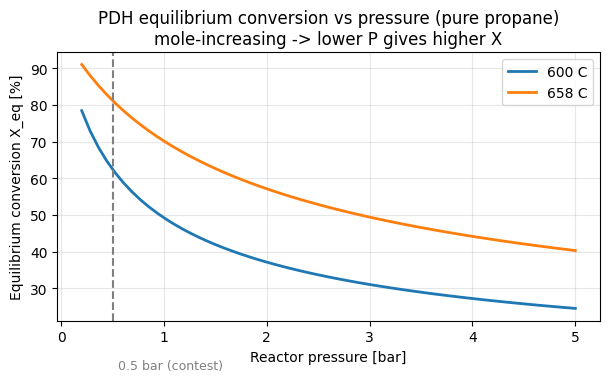

T=600C: 0.3bar->72%  0.5bar->62%  1.0bar->49%  2.0bar->37%  5.0bar->25%
T=658C: 0.3bar->87%  0.5bar->81%  1.0bar->70%  2.0bar->57%  5.0bar->40%


In [2]:
th = PDHThermo()
Ps = np.linspace(0.2, 5.0, 60)
fig, ax = plt.subplots(figsize=(6.2, 4.0))
for T in (873.15, T_IN):
    Keq = th.calc_keq(T)
    r = Keq / (Ps * 1e5)
    X = np.sqrt(r / (1.0 + r))
    ax.plot(Ps, X*100, '-', lw=2, label=f'{T-273.15:.0f} C')
ax.axvline(0.5, ls='--', c='gray'); ax.text(0.55, 8, '0.5 bar (contest)', color='gray', fontsize=9)
ax.set_xlabel('Reactor pressure [bar]'); ax.set_ylabel('Equilibrium conversion X_eq [%]')
ax.set_title('PDH equilibrium conversion vs pressure (pure propane)\nmole-increasing -> lower P gives higher X')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
for T in (873.15, T_IN):
    Keq = th.calc_keq(T)
    print(f'T={T-273.15:.0f}C:', '  '.join(
        f'{p}bar->{math.sqrt((Keq/(p*1e5))/(1+Keq/(p*1e5)))*100:.0f}%' for p in (0.3,0.5,1.0,2.0,5.0)))

## (a)+(b) 軸流深床 PFR に Ergun 圧損を連成 → 0.5 bar では成立しない

軸方向 ODE の状態に全圧 $P$ を追加し、

$$\frac{dP}{dz} = -\left[150\,\frac{(1-\varepsilon_b)^2\,\mu\,u}{\varepsilon_b^3 (\phi d_p)^2} + 1.75\,\frac{(1-\varepsilon_b)\,\rho\,u^2}{\varepsilon_b^3\,\phi d_p}\right]$$

で減衰させる。0.5 bar は低圧なので $\rho\propto P,\ u\propto1/P$ で慣性項が暴走し、深床では数 m で圧力が落ちきる。
現実的な触媒粒径 $d_p$=2–6mm × 床長 $z_{cat}$ で軸流深床を実走し feasibility を見る。


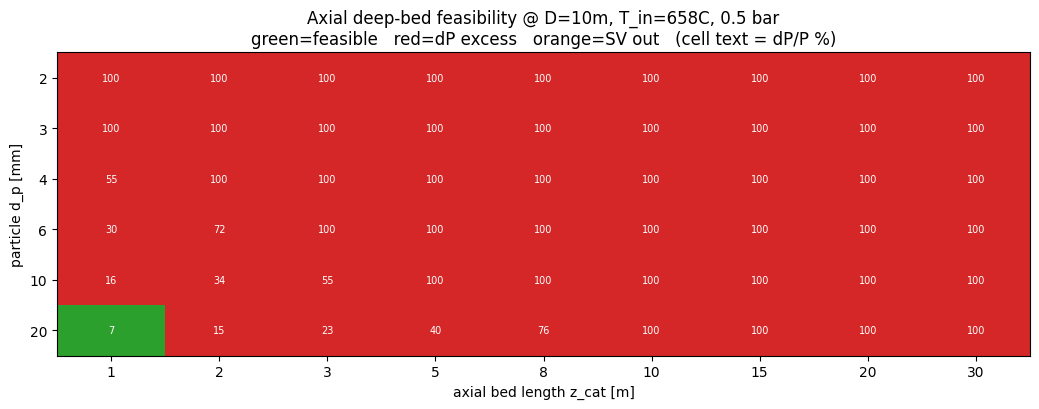

現実的粒径 (2-6mm) × 全床長 で feasible なセル数 = 0 / 36
→ 現実的な 2-6mm 触媒では、軸流深床はどの床長でも 0.5 bar で ΔP 過大(実質全損)。成立しない。


In [3]:
d_ps_mm = [2, 3, 4, 6, 10, 20]
z_cats  = [1, 2, 3, 5, 8, 10, 15, 20, 30]
D, T_in = 10.0, T_IN
status = np.zeros((len(d_ps_mm), len(z_cats)), dtype=int)   # 0 ok, 1 dP, 2 SV, 3 other
dpgrid = np.full(status.shape, np.nan)
for i, dp in enumerate(d_ps_mm):
    for j, z in enumerate(z_cats):
        fx = FixedParams(d_p_m=dp/1000.)
        d = AxialDesign(T_in=T_in, z_cat=float(z), t_cyc=15., D=D)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            r = simulate_swing_reactor_system(d, FEED, fx)
        reason = r.equipment.penalty_reason
        dpgrid[i, j] = min(r.equipment.dP_over_P_actual*100, 999)
        status[i, j] = {'': 0, 'dP_excess': 1, 'sv_out_of_range': 2}.get(reason, 3)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(['#2ca02c', '#d62728', '#ff7f0e', '#7f7f7f'])
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.imshow(status, cmap=cmap, vmin=0, vmax=3, aspect='auto')
ax.set_xticks(range(len(z_cats))); ax.set_xticklabels(z_cats)
ax.set_yticks(range(len(d_ps_mm))); ax.set_yticklabels(d_ps_mm)
ax.set_xlabel('axial bed length z_cat [m]'); ax.set_ylabel('particle d_p [mm]')
ax.set_title(f'Axial deep-bed feasibility @ D={D:.0f}m, T_in={T_in-273.15:.0f}C, 0.5 bar\n'
             'green=feasible   red=dP excess   orange=SV out   (cell text = dP/P %)')
for i in range(len(d_ps_mm)):
    for j in range(len(z_cats)):
        t = (f'{dpgrid[i,j]:.0f}' if status[i,j] in (0, 1) else ('SV' if status[i,j]==2 else '?'))
        ax.text(j, i, t, ha='center', va='center', color='white', fontsize=7)
plt.tight_layout(); plt.show()
real = [d_ps_mm.index(x) for x in (2, 3, 4, 6)]
print('現実的粒径 (2-6mm) × 全床長 で feasible なセル数 =', int((status[real, :] == 0).sum()),
      '/', len(real)*len(z_cats))
print('→ 現実的な 2-6mm 触媒では、軸流深床はどの床長でも 0.5 bar で ΔP 過大(実質全損)。成立しない。')

### (a)+(b) の所見

- 現実的な粒径(2–6mm)では、**どの床長でも軸流深床は 0.5 bar で成立しない**(緑がほぼ無い)。
- **短床は SV 過大**(必要触媒体積↓→並列基数↓→1基流速↑)、**長床は ΔP 過大**(流路長で圧損暴走)。
- 救えるのは数十 mm の大粒径だが、(i)供給範囲外、(ii)粒内拡散律速でキネティクス前提が崩れる、ため物理的に不可。
- ⇒ 圧力(=平衡)で妥協できない以上、残るレバーは **反応器の幾何**。次に Catofin 浅床・多基を見る。


## (c) 解 = Catofin型 浅床・大断面・多基並列スイング

捨てるのは「軸流」ではなく「**深床**」である。Catofin は次の3つで 0.5 bar の圧損を成立させる:

| レバー | 役割 | 圧損への効き |
|---|---|---|
| **浅床 $L_{bed}\le1$m** | 1 基あたり流路長を短く | ΔP $\propto u L$ を直接下げる |
| **多基並列 $N_{online}$** | 大流量を分割 → 1 基あたり流速↓ | $u=Q/(A N_{online})$ で ΔP↓・SV確保 |
| **粒径 $d_p$** | Ergun 粒径項 | $d_p\uparrow$ で ΔP↓(粒内拡散とトレードオフ) |

1 基は $F_{total}/N_{online}$ を軸流 ODE で解き出口を $N_{online}$ 倍する。**床温は HGM 等価熱補償**で
$T_{in}-\Delta T_{max}$ 以上に維持(別ノート `reactor_conversion_ceiling.ipynb`)。
**圧損制約は2段**: 床 ΔP/P<5%、総 ΔP(床×内部品 $K=2$)/P<10%。

下で N_online と d_p を振り、Catofin が現実的 3mm 粒で feasible になることを実証する。


N_online 掃引 (L_bed=0.96m, d_p=3.2mm):  大流量を多基で分割 → 流速↓ → ΔP↓
  N_online= 6: dP/P= 17.9%  X= 0.0%  S= 0.0%  dP_excess


  N_online= 8: dP/P= 11.9%  X= 0.0%  S= 0.0%  dP_excess


  N_online=10: dP/P=  8.8%  X=21.6%  S=82.6%  OK


  N_online=14: dP/P=  5.7%  X=27.2%  S=82.8%  OK


  N_online=18: dP/P=  4.2%  X=31.9%  S=82.8%  OK


  N_online=24: dP/P=  3.5%  X=37.8%  S=82.6%  OK

d_p 掃引 (N_online=24): 粒径で ΔP を微調整 (X はほぼ不変)


  d_p=2mm: dP/P= 7.3%  X=37.7%  OK


  d_p=3mm: dP/P= 3.7%  X=37.8%  OK


  d_p=4mm: dP/P= 3.0%  X=37.7%  OK


  d_p=6mm: dP/P= 2.5%  X=37.5%  OK


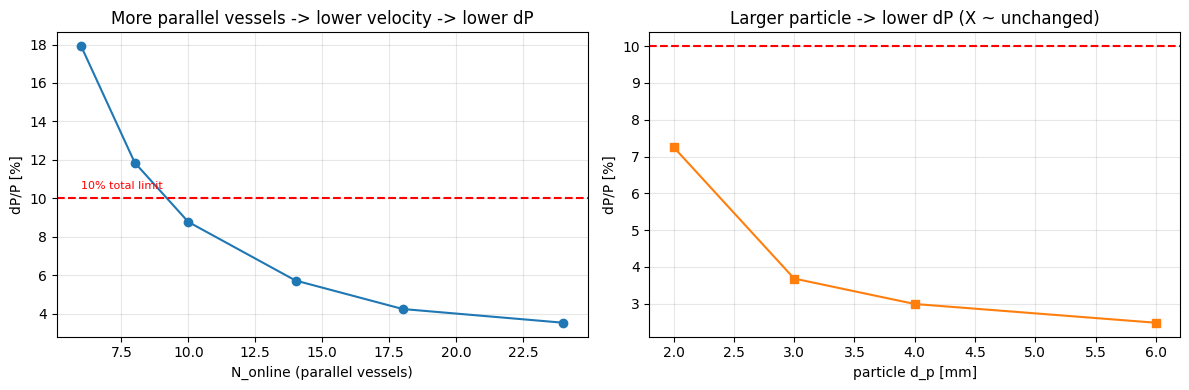

In [4]:
# catofin best #227 設計点
CAT = dict(T_in=T_IN, t_cyc=13.99, D=6.771, L_bed=0.956, N_online=24, d_p=0.003156)
def run_cat(**kw):
    d = dict(CAT); d.update(kw)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = simulate_catofin_reactor_system(CatofinDesignVars(**d), FEED)
    e = r.equipment
    return dict(X=r.performance.Conversion, S=r.performance.Selectivity, dP=e.dP_over_P_actual*100,
                pen=e.penalty_reason or 'OK', Ntot=e.N_reactors_total, Wcat=e.Catalyst_Weight_Total/1000)

print('N_online 掃引 (L_bed=0.96m, d_p=3.2mm):  大流量を多基で分割 → 流速↓ → ΔP↓')
Ns = [6, 8, 10, 14, 18, 24]; dP_N = []
for n in Ns:
    x = run_cat(N_online=n); dP_N.append(x['dP'])
    print(f'  N_online={n:>2}: dP/P={x["dP"]:5.1f}%  X={x["X"]:4.1f}%  S={x["S"]:4.1f}%  {x["pen"]}')
print('\nd_p 掃引 (N_online=24): 粒径で ΔP を微調整 (X はほぼ不変)')
dps = [2, 3, 4, 6]; dP_dp = []
for dp in dps:
    x = run_cat(d_p=dp/1000.); dP_dp.append(x['dP'])
    print(f'  d_p={dp}mm: dP/P={x["dP"]:4.1f}%  X={x["X"]:4.1f}%  {x["pen"]}')

fig, axs = plt.subplots(1, 2, figsize=(12, 4.0))
axs[0].plot(Ns, dP_N, 'o-', color='C0'); axs[0].axhline(10, ls='--', c='r')
axs[0].text(6, 10.5, '10% total limit', color='r', fontsize=8)
axs[0].set_xlabel('N_online (parallel vessels)'); axs[0].set_ylabel('dP/P [%]')
axs[0].set_title('More parallel vessels -> lower velocity -> lower dP'); axs[0].grid(alpha=.3)
axs[1].plot(dps, dP_dp, 's-', color='C1'); axs[1].axhline(10, ls='--', c='r')
axs[1].set_xlabel('particle d_p [mm]'); axs[1].set_ylabel('dP/P [%]')
axs[1].set_title('Larger particle -> lower dP (X ~ unchanged)'); axs[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## (d) 決定的比較と結論 — 軸流深床 vs Catofin 浅床多基

同じ現実的 3mm 触媒・同じ反応器入口で、軸流深床(全 z で破綻)と Catofin 設計点(#227)を並べる。


In [5]:
print('現実的 3mm 触媒, 同入口での比較:')
for z in (5, 10, 20, 30):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ra = simulate_swing_reactor_system(AxialDesign(T_in=T_IN, z_cat=float(z), t_cyc=15., D=10.),
                                           FEED, FixedParams(d_p_m=0.003))
    print(f'  軸流深床 z={z:>3}m d_p=3mm : dP/P={min(ra.equipment.dP_over_P_actual*100,999):5.1f}%  '
          f'{ra.equipment.penalty_reason or "OK"}')
xc = run_cat()
print(f'  Catofin #227 (L_bed=0.96m, N_online=24, d_p=3.2mm):')
print(f'    dP/P={xc["dP"]:.1f}%  X={xc["X"]:.1f}%  S={xc["S"]:.1f}%  '
      f'N_total={xc["Ntot"]}基  触媒={xc["Wcat"]:.0f}t  → feasible ({xc["pen"]})')
print()
print('結論(d): 0.5 bar 低圧は平衡転化率のため不可欠 → 圧力では逃げられない →')
print('  軸流『深床』は現実的粒径で全床長 ΔP 過大 → 浅床(L_bed<=1m)+多基並列(N_online)で')
print('  流路長と流速を同時に下げる Catofin 形式が必然。実機 Lummus Catofin と一致。')

現実的 3mm 触媒, 同入口での比較:


  軸流深床 z=  5m d_p=3mm : dP/P=100.0%  dP_excess


  軸流深床 z= 10m d_p=3mm : dP/P=100.0%  dP_excess


  軸流深床 z= 20m d_p=3mm : dP/P=100.0%  dP_excess


  軸流深床 z= 30m d_p=3mm : dP/P=100.0%  dP_excess


  Catofin #227 (L_bed=0.96m, N_online=24, d_p=3.2mm):
    dP/P=3.5%  X=37.8%  S=82.6%  N_total=96基  触媒=1487t  → feasible (OK)

結論(d): 0.5 bar 低圧は平衡転化率のため不可欠 → 圧力では逃げられない →
  軸流『深床』は現実的粒径で全床長 ΔP 過大 → 浅床(L_bed<=1m)+多基並列(N_online)で
  流路長と流速を同時に下げる Catofin 形式が必然。実機 Lummus Catofin と一致。


### まとめ

- 現実的な 2–6mm 触媒で **軸流深床は 0.5 bar でどの床長でも ΔP 過大**(実質全損)= infeasible。
- **Catofin 浅床・多基並列**は、浅床 $L_{bed}\le1$m で流路長を、$N_{online}$ で空塔速度を同時に下げ、
  現実的 3mm 粒で **ΔP/P≈3.5%(<10%)で feasible**(#227: X=37.8%, N_total=96 基)。
- 捨てたのは「軸流」でなく「**深床**」。低圧の平衡メリットを保ったまま圧損問題を解決した。
- ⇒ レポート結論: **0.5 bar 低圧 PDH は浅床+多基(Catofin)が物理的必然**。実機 Lummus Catofin と一致。

> 径方向流(radial flow)も同じ「流路長と体積の分離」で圧損を解けるが、内部品/分配板/再生時の
> 温度分布の不確かさが大きく、本設計では撤去して Catofin(浅床多基)を採用した。
